In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df_index = pd.read_excel("Economics.xlsx")
df_index.head()

,Unnamed: 0,Year,Month,Interest_rate,Unemployment_rate,Index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
#drop non important column
df_index.drop(columns=['Unnamed: 0', 'Year','Month'], axis=1, inplace=True)
df_index.head()

,Interest_rate,Unemployment_rate,Index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
#check null values
df_index.isnull().sum()

Interest_rate        0
Unemployment_rate    0
Index_price          0
dtype: int64

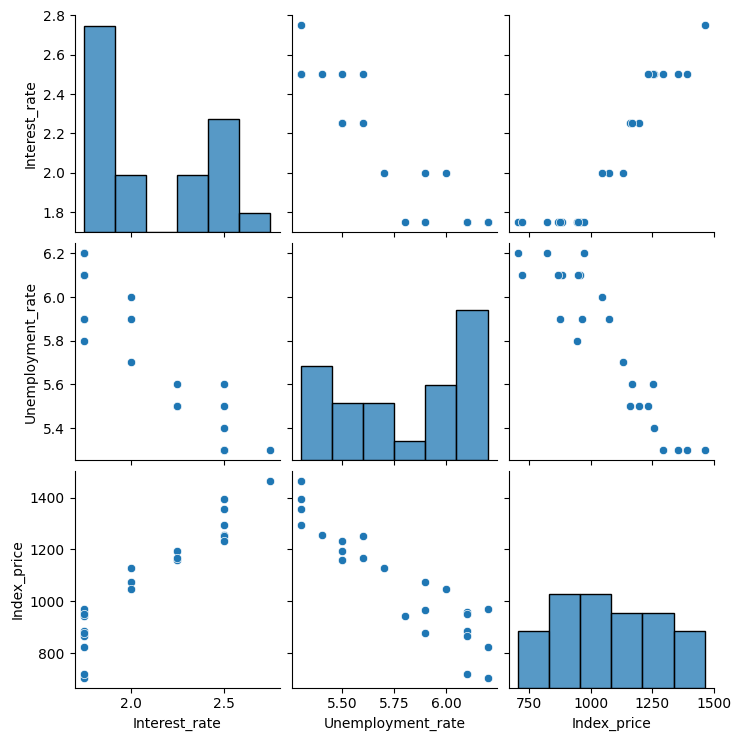

In [8]:
## lets do some visualize
import seaborn as sns 
sns.pairplot(df_index)

In [9]:
df_index.corr()

,Interest_rate,Unemployment_rate,Index_price
Interest_rate,1.000000,-0.925814,0.935793
Unemployment_rate,-0.925814,1.000000,-0.922338
Index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment_rate')

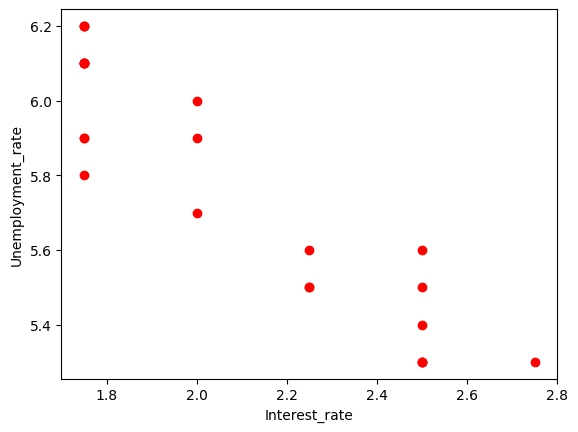

In [11]:
##visualize the datapoint
plt.scatter(df_index['Interest_rate'],df_index['Unemployment_rate'], color="Red")
plt.xlabel('Interest_rate')
plt.ylabel('Unemployment_rate')

In [20]:
x=df_index[["Interest_rate",'Unemployment_rate']]
y=df_index['Index_price']
x.head()

,Interest_rate,Unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [21]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.25, random_state=42)

<Axes: xlabel='Interest_rate', ylabel='Index_price'>

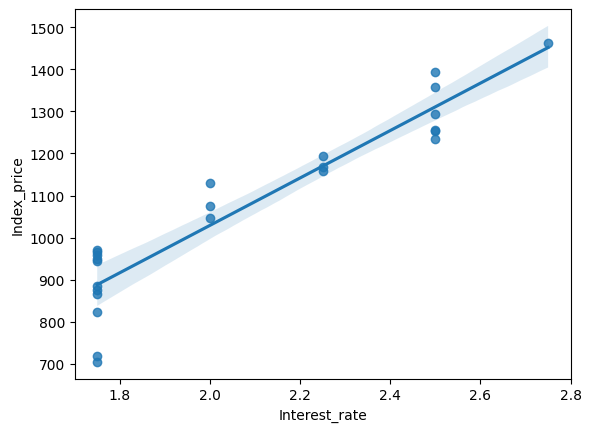

In [24]:
import seaborn as sns
sns.regplot(
    x=df_index['Interest_rate'],
    y=df_index['Index_price']
)

<Axes: xlabel='Interest_rate', ylabel='Unemployment_rate'>

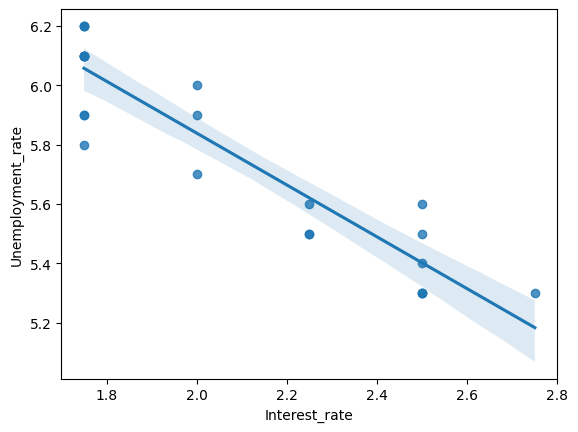

In [25]:
sns.regplot(
    x=df_index['Interest_rate'],
    y=df_index['Unemployment_rate']
)

<Axes: xlabel='Index_price', ylabel='Unemployment_rate'>

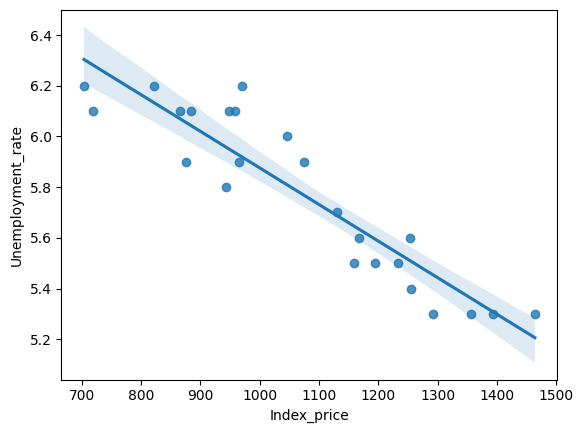

In [26]:
sns.regplot(
    x=df_index['Index_price'],
    y=df_index['Unemployment_rate']
)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [31]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


In [34]:
#cross_val score
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, x_train, y_train,scoring='neg_mean_squared_error', cv=3)
np.mean(validation_score)

np.float64(-5914.828180162392)

In [36]:
#prediction
y_pred = regression.predict(x_test)
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [37]:
## performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306611
73.80444932337099
90.04758423359624


In [38]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.7591371539010254


In [40]:
##adjusted r^2
1-(1-score) * (len(y_test)-1) / (len(y_test)-x_test.shape[1]-1)

0.5985619231683756

### Assumptions

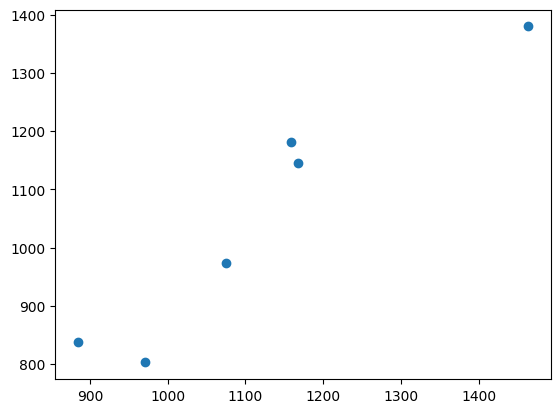

In [41]:
plt.scatter(y_test, y_pred)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: Index_price, dtype: float64


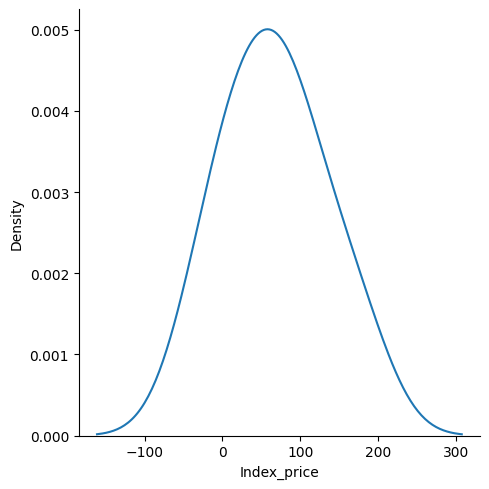

In [43]:
residuals = y_test - y_pred
print(residuals)

#plot the residuals
sns.displot(residuals, kind='kde')

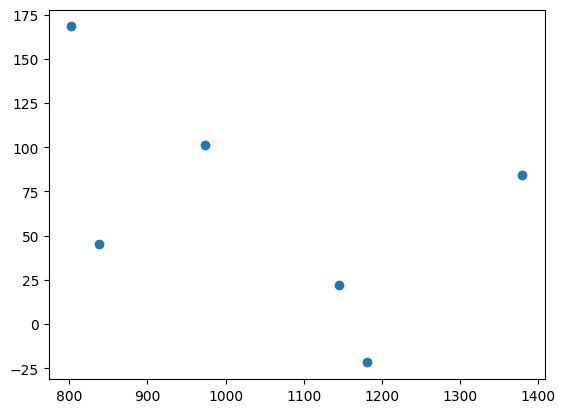

In [44]:
## scatter plot with prediction and residuals
plt.scatter(y_pred, residuals)

In [45]:
## ols of linear regression
import statsmodels.api as sm
model = sm.OLS(y_train,x_train).fit()
prediction = model.predict(x_test)
print(prediction)

[ 127.30223686 -250.70164745  326.390126   -214.91844842  -79.59130481
   91.51903783]


In [46]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            Index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 21 Jun 2026   Prob (F-statistic):                       0.754
Time:                        21:29:51   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [47]:
print(regression.coef_)

[  88.27275507 -116.25716066]
